<div style="background: linear-gradient(to bottom, #461EBE, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Pilot Training Results
Learning curve from the Mac pilot run · generation examples from the latest saved adapter.

</div>

In [17]:
import re, json, textwrap, random, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from io import BytesIO
from PIL import Image, ImageDraw
import cairosvg

sys.path.insert(0, "..")
from brand import BRAND, blue, purple, orange, green, pink, teal, white, black, dark_bg

BG = dark_bg

## 1 · Learning Curve

In [18]:
LOG_DIR  = Path("../logs")
log_file = sorted(LOG_DIR.glob("train_mac_*.log"))[-1]   # latest run
print(f"Log: {log_file.name}  ({log_file.stat().st_size / 1024:.0f} KB)")

train_iters, train_losses = [], []
train_tok_sec, train_tokens, train_peak_mem = [], [], []
val_iters, val_losses = [], []

TRAIN_RE = re.compile(
    r"Iter (\d+): Train loss ([\d.]+), Learning Rate [\d.e+-]+, "
    r"It/sec [\d.]+, Tokens/sec ([\d.]+), Trained Tokens (\d+), Peak mem ([\d.]+) GB"
)
VAL_RE = re.compile(r"Iter (\d+): Val loss ([\d.]+)")

for line in log_file.read_text().splitlines():
    m = TRAIN_RE.match(line)
    if m:
        train_iters.append(int(m.group(1)))
        train_losses.append(float(m.group(2)))
        train_tok_sec.append(float(m.group(3)))
        train_tokens.append(int(m.group(4)))
        train_peak_mem.append(float(m.group(5)))
    m = VAL_RE.match(line)
    if m:
        val_iters.append(int(m.group(1)))
        val_losses.append(float(m.group(2)))

best_i = int(np.argmin(val_losses))
print(f"Train steps : {len(train_iters)}")
print(f"Val   steps : {len(val_iters)}")
print(f"Train loss  : {min(train_losses):.3f} \u2013 {max(train_losses):.3f}")
print(f"Val   loss  : {min(val_losses):.3f} \u2013 {max(val_losses):.3f}")
print(f"Best val    : {val_losses[best_i]:.4f} @ iter {val_iters[best_i]}")
print(f"Throughput  : {np.mean(train_tok_sec):.0f} tok/s avg  |  peak mem {max(train_peak_mem):.2f} GB")
print(f"Trained tok : {train_tokens[-1]:,} total")

Log: train_mac_20260422_111454.log  (2020 KB)
Train steps : 3750
Val   steps : 189
Train loss  : 0.397 – 1.051
Val   loss  : 0.673 – 1.118
Best val    : 0.6730 @ iter 20200
Throughput  : 814 tok/s avg  |  peak mem 14.93 GB
Trained tok : 16,815,886 total


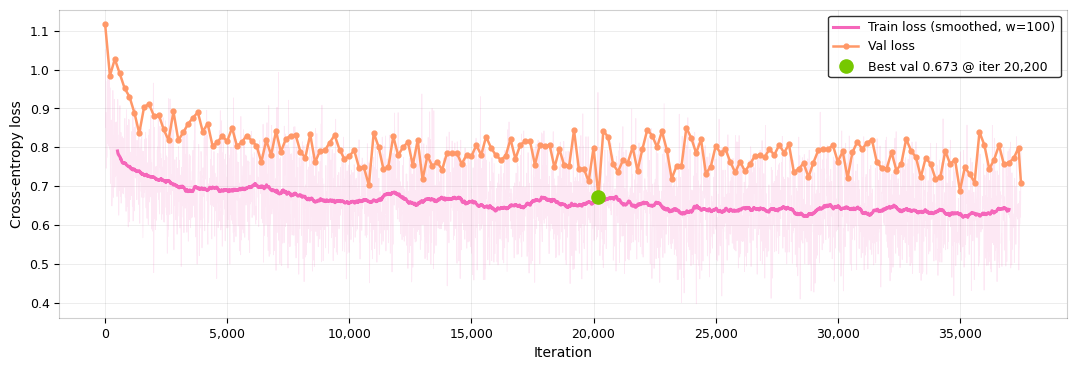

Saved → output/learning_curve.png


In [28]:
from matplotlib.ticker import FuncFormatter

W = 100   # smoothing window (train loss is very noisy per-batch)

fig, ax = plt.subplots(figsize=(13, 4), facecolor="white")
ax.set_facecolor("white")

# Raw train loss (very faint)
ax.plot(train_iters, train_losses, color=pink, alpha=0.15, linewidth=0.6)

# Smoothed train loss
if len(train_losses) >= W:
    s = np.convolve(train_losses, np.ones(W) / W, mode="valid")
    x = train_iters[W // 2 : W // 2 + len(s)]
    ax.plot(x, s, color=pink, linewidth=2.2, label=f"Train loss (smoothed, w={W})")

# Val loss
ax.plot(val_iters, val_losses, color=orange, linewidth=1.8,
        marker="o", markersize=3.5, label="Val loss")

# Best val marker
ax.scatter([val_iters[best_i]], [val_losses[best_i]], color=green, s=90, zorder=5,
           label=f"Best val {val_losses[best_i]:.3f} @ iter {val_iters[best_i]:,}")

for sp in ax.spines.values():
    sp.set_edgecolor("#00000030")
ax.tick_params(colors=black, labelsize=9)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("Iteration", color=black, fontsize=10)
ax.set_ylabel("Cross-entropy loss", color=black, fontsize=10)
#ax.set_title("Pilot — Learning Curve  (Qwen2.5-Coder-1.5B + LoRA, 100k icons, 3 epochs)", color=black, fontsize=12)
ax.legend(facecolor="white", edgecolor="#00000030", labelcolor=black, fontsize=9)
ax.grid(color=black, linewidth=0.5, alpha=0.1)

Path("output").mkdir(exist_ok=True)
plt.savefig("output/learning_curve.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → output/learning_curve.png")

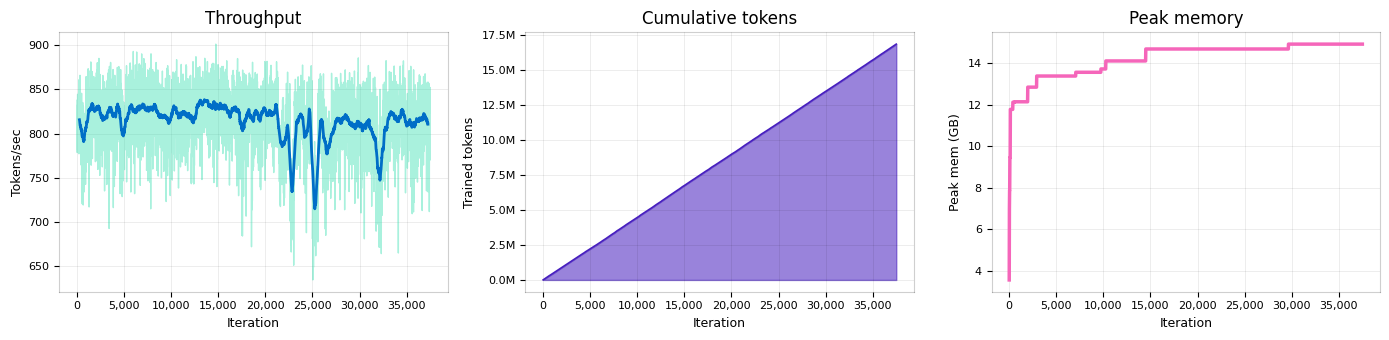

Saved → output/training_diagnostics.png


In [29]:
from matplotlib.ticker import FuncFormatter

smooth_w = 50

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), facecolor="white")

panels = [
    (train_tok_sec, "Tokens/sec",      teal,   "Throughput"),
    (train_tokens,  "Trained tokens",  purple, "Cumulative tokens"),
    (train_peak_mem,"Peak mem (GB)",   pink,   "Peak memory"),
]
for ax, (vals, ylabel, color, title) in zip(axes, panels):
    ax.set_facecolor("white")

    if title == "Throughput":
        ax.plot(train_iters, vals, color=color, linewidth=1.0, alpha=0.4)
        if len(vals) >= smooth_w:
            s = np.convolve(vals, np.ones(smooth_w) / smooth_w, mode="valid")
            xs = train_iters[smooth_w // 2 : smooth_w // 2 + len(s)]
            ax.plot(xs, s, color=blue, linewidth=2.0, zorder=5)
    elif title == "Cumulative tokens":
        vals_m = [v / 1e6 for v in vals]
        ax.fill_between(train_iters, vals_m, alpha=0.55, color=color)
        ax.plot(train_iters, vals_m, color=color, linewidth=1.2)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}M"))
    else:
        ax.plot(train_iters, vals, color=color, linewidth=2.5, alpha=1)

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    for sp in ax.spines.values():
        sp.set_edgecolor("#00000030")
    ax.tick_params(colors=black, labelsize=8)
    ax.set_xlabel("Iteration", color=black, fontsize=9)
    ax.set_ylabel(ylabel, color=black, fontsize=9)
    ax.set_title(title, color=black, fontsize=12)
    ax.grid(color=black, linewidth=0.5, alpha=0.1)

#plt.suptitle("Training diagnostics", color=black, fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("output/training_diagnostics.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → output/training_diagnostics.png")

## 2 · Sample Test Icons

In [21]:
# Render helpers — defined here so the reference preview below can use them
CARD_SZ  = 160
ICON_PAD = 16
CORNER   = 12

def _rgba(h, a=255):
    h = h.lstrip("#")
    return (int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16), a)

def make_card(svg_text, color):
    m = re.search(r"(<svg[\s\S]*?</svg>)", svg_text, re.IGNORECASE)
    svg = m.group(1) if m else svg_text
    svg = svg.replace("currentColor", color)
    svg = re.sub(r'(fill|stroke)="(black|#000|#000000)"', rf'\1="{color}"', svg)

    icon_sz = CARD_SZ - ICON_PAD * 2
    card = Image.new("RGBA", (CARD_SZ, CARD_SZ), (0, 0, 0, 0))
    mask = Image.new("L",    (CARD_SZ, CARD_SZ), 0)
    ImageDraw.Draw(mask).rounded_rectangle(
        [0, 0, CARD_SZ - 1, CARD_SZ - 1], radius=CORNER, fill=255
    )
    card.paste(Image.new("RGBA", (CARD_SZ, CARD_SZ), (255, 255, 255, 255)), mask=mask)

    try:
        png  = cairosvg.svg2png(bytestring=svg.encode(), output_width=icon_sz, output_height=icon_sz)
        icon = Image.open(BytesIO(png)).convert("RGBA")
        card.paste(icon, (ICON_PAD, ICON_PAD), icon)
    except Exception:
        ImageDraw.Draw(card).text(
            (CARD_SZ // 2, CARD_SZ // 2), "not rendered", fill=(0, 0, 0, 255), anchor="mm"
        )

    ImageDraw.Draw(card).rounded_rectangle(
        [0, 0, CARD_SZ - 1, CARD_SZ - 1], radius=CORNER, outline=_rgba(color), width=3
    )
    return card

In [22]:
TEST_PATH = Path("../data/pilot/test.jsonl")
N_SHOW    = 7
MIN_IDX   = 5   # skip trivial 1-path curriculum icons at the front

all_records = [json.loads(l) for l in TEST_PATH.read_text().splitlines() if l.strip()]
pool   = all_records[MIN_IDX:]
sample = random.sample(pool, min(N_SHOW, len(pool)))

def extract(record):
    msgs = {m["role"]: m["content"] for m in record["messages"]}
    return {
        "prompt":    msgs["user"].replace("Generate an SVG icon: ", ""),
        "reference": msgs["assistant"],
        "system":    msgs["system"],
        "zeroshot":  None,
        "generated": None,
    }

records = [extract(r) for r in sample]
print(f"Sampled {len(records)} icons:")
for r in records:
    print(f"  · {r['prompt'][:70]}")

Sampled 7 icons:
  · paint palette with paintbrush, simple line icon
  · checkmark next to file code icon
  · contact book icon with phone symbol
  · music note inside circle, simple line style
  · bold image icon with mountains and sun
  · filled letter "A" with curved lines, browser icon
  · gear icon with circular border, settings symbol


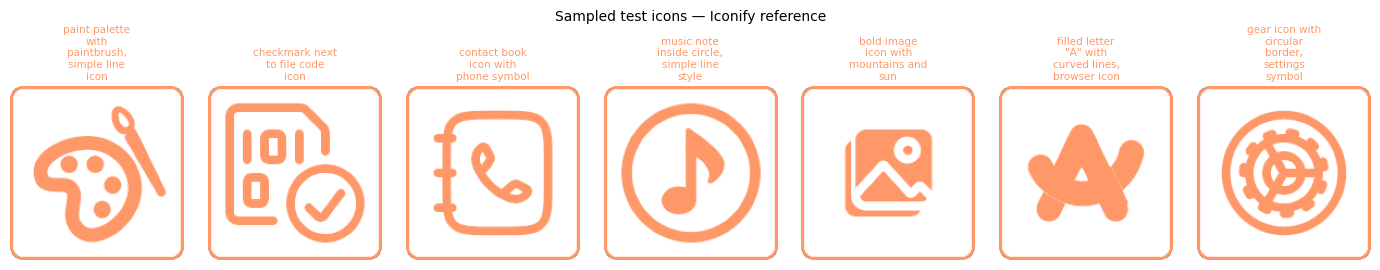

In [ ]:
# Reference icons preview — re-run sampling cell above for a different set
fig, axes = plt.subplots(1, len(records), figsize=(len(records) * 2.0, 2.6), facecolor="white")
for ax, rec in zip(axes, records):
    ax.set_facecolor("white")
    ax.axis("off")
    ax.imshow(make_card(rec["reference"], orange))
    wrapped = "\n".join(textwrap.wrap(rec["prompt"], width=14))
    ax.set_title(wrapped, color=black, fontsize=7.5, pad=5, multialignment="center")

#fig.suptitle("Sampled test icons — Iconify reference", color=black, fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

## 3 · Generate
Zero-shot first (base model, no adapter), then fine-tuned. Generated sequentially to avoid holding two model instances in memory.

In [24]:
from mlx_lm import load, generate as mlx_generate

MODEL = "mlx-community/Qwen2.5-Coder-1.5B-Instruct-4bit"

def run_generation(mdl, tok, records, key):
    for i, rec in enumerate(records):
        messages = [
            {"role": "system", "content": rec["system"]},
            {"role": "user",   "content": f"Generate an SVG icon: {rec['prompt']}"},
        ]
        prompt_text = tok.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False
        )
        rec[key] = mlx_generate(mdl, tok, prompt=prompt_text, max_tokens=1024, verbose=False)
        print(f"  [{i+1}/{len(records)}] {rec['prompt'][:60]}")

In [25]:
print("Loading base model (zero-shot, no adapter)…")
model_base, tokenizer = load(MODEL)
print("Generating…")
run_generation(model_base, tokenizer, records, key="zeroshot")
del model_base
print("Zero-shot done.")

Loading base model (zero-shot, no adapter)…


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 98818.68it/s]


Generating…
  [1/7] paint palette with paintbrush, simple line icon
  [2/7] checkmark next to file code icon
  [3/7] contact book icon with phone symbol
  [4/7] music note inside circle, simple line style
  [5/7] bold image icon with mountains and sun
  [6/7] filled letter "A" with curved lines, browser icon
  [7/7] gear icon with circular border, settings symbol
Zero-shot done.


In [26]:
ADAPTER = "../models/pilot-lora"   # adapters.safetensors = latest checkpoint

print("Loading fine-tuned model (with adapter)…")
model_ft, tokenizer = load(MODEL, adapter_path=ADAPTER)
print("Generating…")
run_generation(model_ft, tokenizer, records, key="generated")
print("Fine-tuned done.")

Loading fine-tuned model (with adapter)…


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 231587.34it/s]


Generating…
  [1/7] paint palette with paintbrush, simple line icon
  [2/7] checkmark next to file code icon
  [3/7] contact book icon with phone symbol
  [4/7] music note inside circle, simple line style
  [5/7] bold image icon with mountains and sun
  [6/7] filled letter "A" with curved lines, browser icon
  [7/7] gear icon with circular border, settings symbol
Fine-tuned done.


## 4 · Comparison Grid

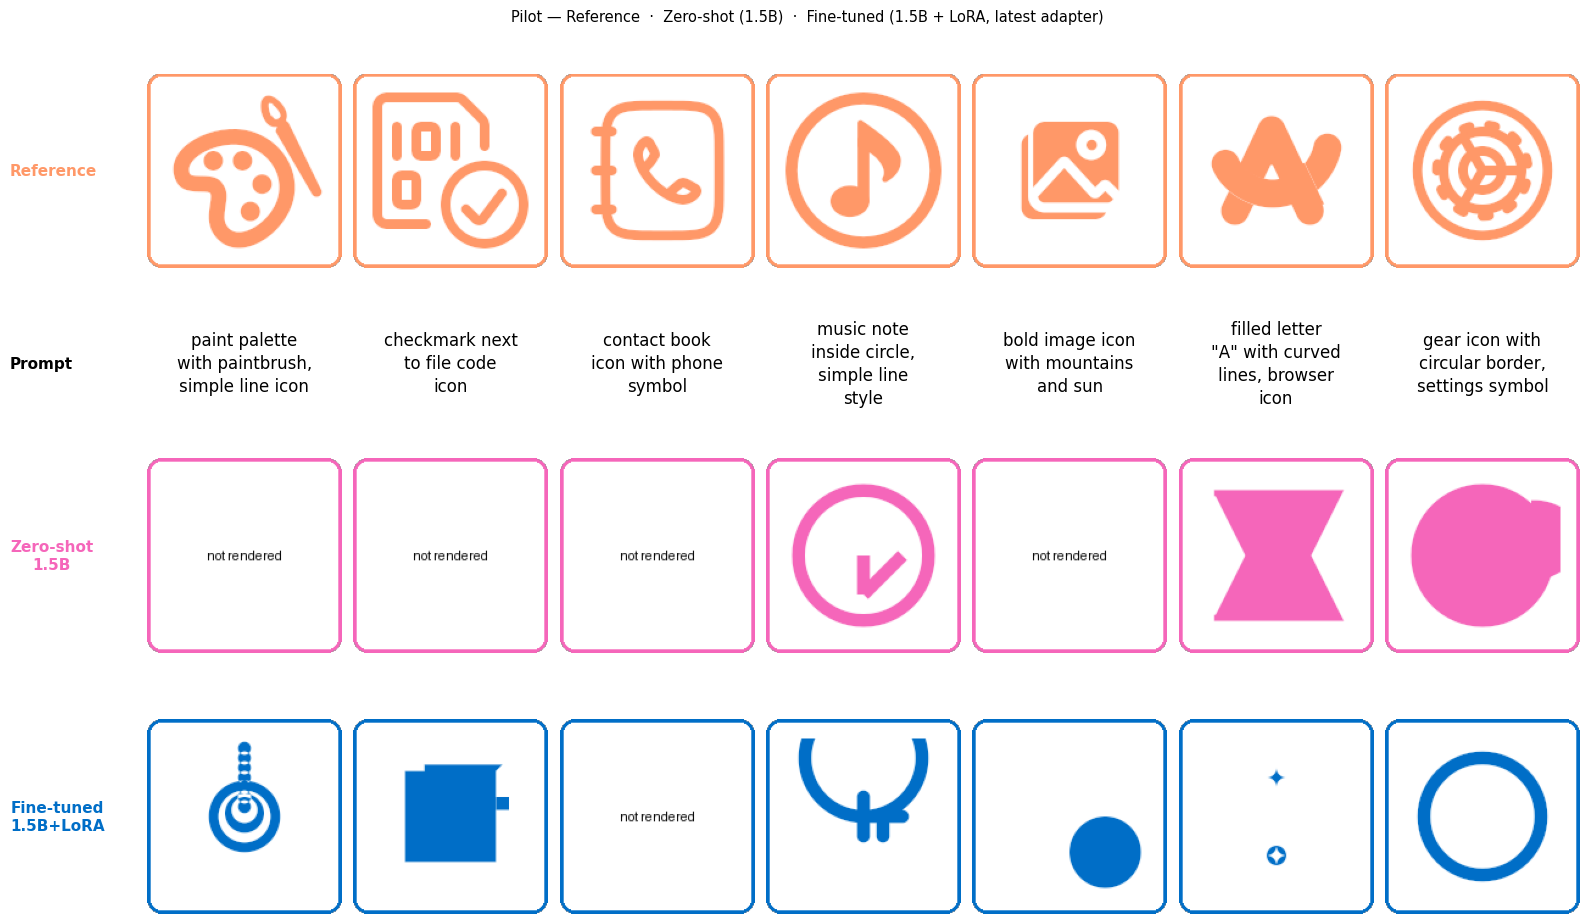

Saved → output/pilot_comparison_grid.png


In [27]:
ROW_META = [
    ("Reference",             orange, "reference"),
    ("Prompt",                black,  "prompt"),
    ("Zero-shot\n1.5B",       pink,   "zeroshot"),
    ("Fine-tuned\n1.5B+LoRA", blue,   "generated"),
]
N_ROWS = len(ROW_META)
N_COLS = len(records)

fig = plt.figure(figsize=(N_COLS * 2.3, N_ROWS * 2.4), facecolor="white")
gs  = gridspec.GridSpec(
    N_ROWS, N_COLS, figure=fig,
    height_ratios=[2.2, 0.75, 2.2, 2.2],
    hspace=0.30, wspace=0.06,
    left=0.09, right=0.98, top=0.91, bottom=0.02,
)

col0_axes = {}
for col_i, rec in enumerate(records):
    for row_i, (label, color, key) in enumerate(ROW_META):
        ax = fig.add_subplot(gs[row_i, col_i])
        ax.set_facecolor("white")
        ax.axis("off")
        if col_i == 0:
            col0_axes[row_i] = ax

        if key == "prompt":
            wrapped = "\n".join(textwrap.wrap(rec["prompt"], width=16))
            ax.text(0.5, 0.5, wrapped, ha="center", va="center", fontsize=12,
                    color=color, transform=ax.transAxes,
                    multialignment="center", linespacing=1.35)
        else:
            ax.imshow(make_card(rec[key], color))

for row_i, (label, color, _) in enumerate(ROW_META):
    pos = col0_axes[row_i].get_position()
    fig.text(
        0.005, pos.y0 + pos.height / 2, label,
        ha="left", va="center", fontsize=11, color=color,
        fontweight="bold", multialignment="center",
    )

fig.suptitle(
    "Pilot — Reference  ·  Zero-shot (1.5B)  ·  Fine-tuned (1.5B + LoRA, latest adapter)",
    color=black, fontsize=10.5, y=0.97,
)

Path("output").mkdir(exist_ok=True)
plt.savefig("output/pilot_comparison_grid.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → output/pilot_comparison_grid.png")